In [1]:
import pandas as pd
import numpy as np

## Create or load a dataframe

### First way: a dictionary

In [2]:
data = pd.DataFrame({'A': [1,2,3], 'B': ["Name", 'Cousin', 'Sister']})

In [3]:
data

,A,B
0,1,Name
1,2,Cousin
2,3,Sister


### Second way: a list

In [4]:
data = pd.DataFrame(np.random.normal(0, 1, size=(10,3)))

In [5]:
data

,0,1,2
0,0.403252,2.331570,-0.006519
1,-0.811959,-0.099053,-1.089078
2,-0.103949,-1.386934,0.641010
3,-0.802703,-0.254293,-1.037519
4,0.762987,0.755253,-0.321067
5,1.463754,1.246273,-0.243808
6,2.337059,-1.072922,-1.563334
7,0.818790,0.415455,1.381983
8,1.640706,0.255688,-0.561262
9,-0.193841,0.015289,0.010653


There are no columns names! We can set them....

In [6]:
data.columns = ['First Column', 'Column 1', 'A']

In [7]:
data

,First Column,Column 1,A
0,0.403252,2.331570,-0.006519
1,-0.811959,-0.099053,-1.089078
2,-0.103949,-1.386934,0.641010
3,-0.802703,-0.254293,-1.037519
4,0.762987,0.755253,-0.321067
5,1.463754,1.246273,-0.243808
6,2.337059,-1.072922,-1.563334
7,0.818790,0.415455,1.381983
8,1.640706,0.255688,-0.561262
9,-0.193841,0.015289,0.010653


## Exercise 1

Create a pandas dataframe having 4 columns and 1000 rows, where:

- first column is a year of birth column, where year are integers from 1950 to 2000, distribution being uniform
- second column is a female column, where gender can be either 1 or 0, distribution should be binomial with p=0.55
- third column is a height column, where height is normal of mean 175 and standard deviation of 7 centimetres for M
- fourth column is a price column, price being a two digit number going from 10 to 100. This should be a Poisson distribution with lambda=10.

Use numpy functions to compute the random distributions.

In [8]:
n = 10000

birth = np.random.randint(1950, 2001, n)
gender = np.random.binomial(n=1, p=0.55, size=n)
height = np.random.normal(loc=175, scale=7, size=n) 
price = np.random.poisson(lam=10, size=n)


df = pd.DataFrame({
    "birth": birth,
    "gedder": gender,
    "height": height,
    "price": price
    
})

In [9]:
df

,birth,gedder,height,price
0,1986,1,178.170010,6
1,1957,0,175.210514,11
2,1964,1,176.882684,10
3,1954,0,174.781185,12
4,1966,0,189.039293,10
...,...,...,...,...
9995,1988,1,170.718288,11
9996,1971,0,170.869123,10
9997,1980,0,168.161814,14
9998,1961,1,171.187290,10


### Load from an existing dataset (for example a csv)

In [15]:
data = pd.read_csv('../dataset/titanic/train.csv')

In [16]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We can use the describe function to have some statistics summary on each column (except for the Name one)

In [17]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

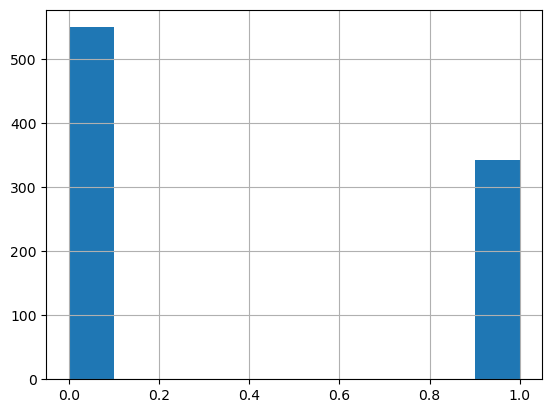

In [18]:
data['Survived'].hist()

## Exercise 2

Plot data for Pclass, Age and Fare as histograms. What can you say about data?


## How to select data in Pandas?

In SQL we can select data from this database, let us call it Titanic, by doing:
```
SELECT *
FROM Titanic
```
This corresponds to calling the variable 
```
data
```

If we want to select only certain columns, in SQL we will do:

SELECT Pclass, Name
FROM Titanic

In pandas, we can call:

In [20]:
data[['Pclass', 'Name']]

,Pclass,Name
0,3,Mr. Owen Harris Braund
1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...
2,3,Miss. Laina Heikkinen
3,1,Mrs. Jacques Heath (Lily May Peel) Futrelle
4,3,Mr. William Henry Allen
...,...,...
882,2,Rev. Juozas Montvila
883,1,Miss. Margaret Edith Graham
884,3,Miss. Catherine Helen Johnston
885,1,Mr. Karl Howell Behr


In SQL we can change a column value, for example making a division, by doing:
```
SELECT "Siblings/Spouses Aboard", "Parents/Children Aboard","Parents/Children Aboard" + "Siblings/Spouses Aboard" as family
FROM Titanic
```
In Pandas we can not do this directly, we need to create a new column:

In [21]:
data['Family'] = data['Siblings/Spouses Aboard'] + data['Parents/Children Aboard']

In [22]:
data[['Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Family']]

,Siblings/Spouses Aboard,Parents/Children Aboard,Family
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0
...,...,...,...
882,0,0,0
883,0,0,0
884,1,2,3
885,0,0,0


The limit value can be given in two different ways:

```
data.head(n)

data[:n]
```

It is possible also, differently from SQL, to easily select the m to n value



In [23]:
data.head(10)

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,0
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,0
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,0
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1


In [24]:
data[:10]

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,1
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,0
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,0
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,0
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1


In [25]:
data[134:145]

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
134,0,2,Mr. Emile Richard,male,23.0,0,0,15.0458,0
135,1,1,Miss. Helen Monypeny Newsom,female,19.0,0,2,26.2833,2
136,0,1,Mr. Jacques Heath Futrelle,male,37.0,1,0,53.1000,1
137,0,3,Mr. Olaf Elon Osen,male,16.0,0,0,9.2167,0
138,0,1,Mr. Victor Giglio,male,24.0,0,0,79.2000,0
139,0,3,Mrs. Joseph (Sultana) Boulos,female,40.0,0,2,15.2458,2
140,1,3,Miss. Anna Sofia Nysten,female,22.0,0,0,7.7500,0
141,1,3,Mrs. Pekka Pietari (Elin Matilda Dolck) Hakkar...,female,24.0,1,0,15.8500,1
142,0,3,Mr. Jeremiah Burke,male,19.0,0,0,6.7500,0
143,0,2,Mr. Edgardo Samuel Andrew,male,18.0,0,0,11.5000,0


## Exercise 3
Select columns Sex, Age and Fare. 

Select last 50 data points for the three columns


In [20]:
data[-50:]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C
844,845,0,3,"Culumovic, Mr. Jeso",male,17.0,0,0,315090,8.6625,NaN,S
845,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
847,848,0,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.0000,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S


## The where clause

In SQL we can filter the data by using the WHERE clause. For example, to find all the survivor we can do:
```
SELECT * 
FROM Titanic
WHERE Survived=1
```

In Pandas, we can filter it by adding a condition
```
data[data['Survived'] == 1]
```

If we want to save the dataset for further analysis, we can assign it to a variable:
```
data_survived = data[data['Survived'] == 1]
```

In [26]:
data[data['Survived'] == 1]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,0
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,2
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1
...,...,...,...,...,...,...,...,...,...
871,1,3,Miss. Adele Kiamie Najib,female,15.0,0,0,7.2250,0
875,1,1,Mrs. Thomas Jr (Lily Alexenia Wilson) Potter,female,56.0,0,1,83.1583,1
876,1,2,Mrs. William (Imanita Parrish Hall) Shelley,female,25.0,0,1,26.0000,1
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000,0


In SQL we can use different conditions by using AND and OR:

```
SELECT *
FROM Titanic
WHERE Sex='female' AND Age > 30
```

In pandas the AND condition is not the same "and" as usual in Pyhon, but we use the bitwise comparison &

```
data[(data['Sex'] == 'female' ) & data['Age'] > 30)]

```



In [27]:
data[(data['Sex'] == 'female' ) & (data['Age'] > 30)]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,1
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,1
11,1,1,Miss. Elizabeth Bonnell,female,58.0,0,0,26.5500,0
15,1,2,Mrs. (Mary D Kingcome) Hewlett,female,55.0,0,0,16.0000,0
18,0,3,Mrs. Julius (Emelia Maria Vandemoortele) Vande...,female,31.0,1,0,18.0000,1
...,...,...,...,...,...,...,...,...,...
858,1,1,Mrs. Frederick Joel (Margaret Welles Barron) S...,female,48.0,0,0,25.9292,0
861,1,2,Mrs. (Karolina) Bystrom,female,42.0,0,0,13.0000,0
867,1,1,Mrs. Richard Leonard (Sallie Monypeny) Beckwith,female,47.0,1,1,52.5542,2
875,1,1,Mrs. Thomas Jr (Lily Alexenia Wilson) Potter,female,56.0,0,1,83.1583,1


The same for OR:

```
SELECT *
FROM Titanic
WHERE Age> 65 or Age < 18
```

In Pandas the OR is translated with the bitwise operation |
```
data[(data['Age'] < 18) | (data['Age'] > 65)]
```


In [28]:
data[(data['Age'] < 18) | (data['Age'] > 65)]


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,4
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,1
10,1,3,Miss. Marguerite Rut Sandstrom,female,4.0,1,1,16.7000,2
14,0,3,Miss. Hulda Amanda Adolfina Vestrom,female,14.0,0,0,7.8542,0
16,0,3,Master. Eugene Rice,male,2.0,4,1,29.1250,5
...,...,...,...,...,...,...,...,...,...
849,1,1,Miss. Mary Conover Lines,female,16.0,0,1,39.4000,1
859,0,3,Miss. Dorothy Edith Sage,female,14.0,8,2,69.5500,10
865,1,3,Master. Harold Theodor Johnson,male,4.0,1,1,11.1333,2
871,1,3,Miss. Adele Kiamie Najib,female,15.0,0,0,7.2250,0


To select only some columns, you can add the list of variable at the end of the command, as for the select command

In SQL

```
SELECT Age, Survived
FROM Titanic
WHERE Age> 65 or Age < 18
```

In Pandas:
```
data[(data['Age'] < 18) | (data['Age'] > 65)][['Age', 'Survived']]
```

In [29]:
data[(data['Age'] < 18) | (data['Age'] > 65)][['Age', 'Survived']]


,Age,Survived
7,2.0,0
9,14.0,1
10,4.0,1
14,14.0,0
16,2.0,0
...,...,...
849,16.0,1
859,14.0,0
865,4.0,1
871,15.0,1


In [30]:
data['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 27.  , 54.  ,  2.  , 14.  ,  4.  ,
       58.  , 20.  , 39.  , 55.  , 23.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 24.  , 40.  , 48.  , 18.  , 66.  , 42.  , 21.  ,
        3.  , 30.  , 16.  ,  7.  , 49.  , 29.  , 65.  , 46.  , 28.5 ,
        5.  , 11.  , 45.  , 64.  , 17.  , 32.  , 25.  ,  0.83, 33.  ,
       59.  , 71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  ,
       36.5 , 51.  , 55.5 , 40.5 , 44.  ,  1.  , 60.  , 61.  , 56.  ,
       50.  , 36.  , 45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 57.  ,
       23.5 ,  0.92, 43.  , 10.  , 13.  ,  0.75, 69.  , 53.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

Null checking is done with the methods notna() and isna()

In [31]:
data.isna()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
882,False,False,False,False,False,False,False,False,False
883,False,False,False,False,False,False,False,False,False
884,False,False,False,False,False,False,False,False,False
885,False,False,False,False,False,False,False,False,False


If we want to see for columns, we can do:

In [32]:
data.isna().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
Family                     0
dtype: int64

There are no missing values for this dataframe.

**Exercice 4**

Select all rows where age is smaller than 25 and show the columns 'Age' and 'Survived'

Select all rows where sex if Female, age is smaller than 60. Plot a histogram for the Survived column for this selection.

Select all rows where sex if male, PClass is 3.  Plot a histogram for the Survived column for this selection.

Select all rows where sex if male, PClass is 1.  Plot a histogram for the Survived column for this selection.

Select all rows where sex if Female or Pclass is 1. Plot a histogram for the Survived column for this selection.


array([[<Axes: title={'center': 'Survived'}>]], dtype=object)

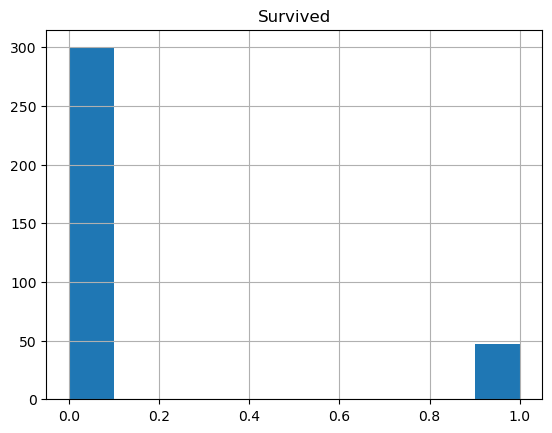

In [27]:
data[data['Age'] < 25][['Age','Survived']]
data[(data['Sex'] == 'male')&(data['Pclass'] == 3)][['Survived']].hist()

## The Group By Clause

In SQL it is possible to group by columns to understand the data. For example, let us consider that we want to understand how many people have survived with respect to the Sex. We can do:

```
SELECT Survived, Sex, COUNT(Sex), 
FROM Titanic
GROUP BY Survived, Sex
```

In pandas it becomes:


In [33]:
data.groupby(['Survived', 'Sex']).count()

Pclass  Name  Age  Siblings/Spouses Aboard  \
Survived Sex                                                  
0        female      81    81   81                       81   
         male       464   464  464                      464   
1        female     233   233  233                      233   
         male       109   109  109                      109   

                 Parents/Children Aboard  Fare  Family  
Survived Sex                                            
0        female                       81    81      81  
         male                        464   464     464  
1        female                      233   233     233  
         male                        109   109     109

if we look at the type, this is not a dataframe. This can be quite cumbersome in the future, so we can call the reset_index() property to return a proper dataframe

In [30]:
print(type(data.groupby(['Survived', 'Sex'])['Sex'].count()))
data.groupby(['Survived', 'Sex'])['Sex'].count()

<class 'pandas.core.series.Series'>


Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: Sex, dtype: int64

In [31]:
print(type(data.groupby(['Survived', 'Sex']).count().reset_index()))
data.groupby(['Survived', 'Sex'])['Sex'].count().reset_index()

<class 'pandas.core.frame.DataFrame'>


ValueError: cannot insert Sex, already exists

In [36]:
data.groupby(['Survived', 'Sex']).count().reset_index()[['Survived', 'Sex', 'Age']].rename(columns={'Age': 'Count'})

,Survived,Sex,Count
0,0,female,81
1,0,male,464
2,1,female,233
3,1,male,109


We can have multiple values computed, for example we would like to do:

```
SELECT Survived, AVG(Age), STD(Age)
FROM Titanic
GROUP BY Survived
```

In pandas it becomes

In [37]:
data.groupby('Survived')['Age'].agg(["median", "mean", 'std']).reset_index()

,Survived,median,mean,std
0,0,28.0,30.138532,13.898317
1,1,28.0,28.408392,14.427863


In [38]:
data.groupby('Survived')['Fare'].agg(["median", "mean", 'std']).reset_index()

,Survived,median,mean,std
0,0,10.5,22.208584,31.484153
1,1,26.0,48.395408,66.596998


## Exercise 4

Compute the survival rate for both male and female.

Compute the mean and std for age group for passangers in 1, 2 and 3 class.

Compute the mean and std for age group for passangers in 1, 2 and 3 class, for both male and female.

Compute the mean and std for fare for passangers in 1, 2 and 3 class, for both male and female.



In [32]:
data.groupby('Sex')['Survived'].agg(["mean"]).reset_index()

,Sex,mean
0,female,0.742038
1,male,0.188908


## Order By

In SQL we can easily order the database by using a column.

```
SELECT Age, Sex
FROM Titanic
ORDER BY Age DESC
```

In Pandas it becomes:

```
data.sort_values('Age')[['Age', 'Sex']]
```

In [39]:
data.sort_values('Age')[['Age', 'Sex']]

,Age,Sex
799,0.42,male
751,0.67,male
641,0.75,female
466,0.75,female
827,0.83,male
...,...,...
115,70.50,male
490,71.00,male
95,71.00,male
847,74.00,male


In [40]:
data.sort_values('Age', ascending=False)[['Age', 'Sex']]

,Age,Sex
627,80.00,male
847,74.00,male
490,71.00,male
95,71.00,male
115,70.50,male
...,...,...
77,0.83,male
466,0.75,female
641,0.75,female
751,0.67,male


## Exercise 5


Select all male passangers who survived and order them by age (descending).

Select all male passangers who survived and in first class and order them by age (descending).

Select all male passangers who survived and in third class and order them by age (descending).

Order all passangers by fare (ascending). What can you notice about the PClass?



## Same basic data cleanings

### Change values in a column by using apply

In [50]:
def set_gender(x):
    if x == 'male':
        return 1
    else:
        return 0

data['Sex'] = data['Sex'].apply(lambda x: 1 if x=='male' else 0)

We can use apply for example to extract the titles from the names

In [51]:
data['title'] = data['Name'].apply(lambda x: x.split('.')[0])

In [52]:
data['title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

In [53]:
data.groupby(['title'])['Name'].count()

title
Capt              1
Col               2
Don               1
Dr                7
Jonkheer          1
Lady              1
Major             2
Master           40
Miss            182
Mlle              2
Mme               1
Mr              513
Mrs             125
Ms                1
Rev               6
Sir               1
the Countess      1
Name: Name, dtype: int64

In [54]:
def map_title(title):
    title_mapping = {
        'Mr': 'Mister', 
        'Mrs': 'Madame', 
        'Miss': 'Miss', 
        'Master': 'Master', 
        'Don': 'Other', 
        'Rev': 'Other', 
        'Dr': 'Other', 
        'Mme': 'Madame', 
        'Ms': 'Miss',
        'Major': 'Other', 
        'Lady': 'Other', 
        'Sir': 'Other', 
        'Mlle': 'Miss', 
        'Col': 'Other', 
        'Capt': 'Other', 
        'the Countess': 'Other',
        'Jonkheer': 'Other'
    }
    return title_mapping[title]
    
data['title'] = data['title'].apply(lambda x: map_title(x))

In [55]:
data.groupby(['title'])['Name'].count()

title
Madame    126
Master     40
Miss      185
Mister    513
Other      23
Name: Name, dtype: int64

In [56]:
survived_title = data.groupby(['Survived', 'title'])['Name'].count().reset_index().rename(columns={'Name': 'Count'})

In [57]:
survived_title.sort_values('title')

,Survived,title,Count
0,0,Madame,26
5,1,Madame,100
1,0,Master,17
6,1,Master,23
2,0,Miss,55
7,1,Miss,130
3,0,Mister,432
8,1,Mister,81
4,0,Other,15
9,1,Other,8


In [65]:
for title in survived_title['title'].unique():
    data_title = data[data['title'] == title]
    print(f'{title} survived percentage: {len(data_title[data_title["Survived"] == 1])/len(data_title)}')

Madame survived percentage: 0.7936507936507936
Master survived percentage: 0.575
Miss survived percentage: 0.7027027027027027
Mister survived percentage: 0.15789473684210525
Other survived percentage: 0.34782608695652173


## Exercise 6


Create a new column Age_Group with following age bands:
- < 18
- 18-25
- 26-45
- 46-60
- 61+

Create a new column Fare_Group with following fare bands:
- < 20
- 20-50
- 50-100
- 100-200
- 200+

Map the titles to either:
- Mister
- Madame
- Miss
- Other

How did you choose this mapping? Compute the survival rate for each title. How does it compare to the survival rate with respect to the variable Sex?

## Merging tables

In [101]:
df1 = pd.DataFrame({"A": [1,2,3, 4], "B": [2,3,4, 4]})
df2 = pd.DataFrame({"A": [1, 3 ,3, 5], "C": [2, 2, 5, 1]})

In [102]:
df1

,A,B
0,1,2
1,2,3
2,3,4
3,4,4


In [103]:
df2

,A,C
0,1,2
1,3,2
2,3,5
3,5,1


In [109]:
print('INNER JOIN')

df1.merge(df2, on="A")

INNER JOIN


,A,B,C
0,1,2,2
1,3,4,2
2,3,4,5


We return all indexes that are in both DataFrame

In [110]:
print('LEFT JOIN')

df1.merge(df2, how='left', on="A")

LEFT JOIN


,A,B,C
0,1,2,2.0
1,2,3,NaN
2,3,4,2.0
3,3,4,5.0
4,4,4,NaN


We return all indexes that are in the first dataframe (the left one). If data is missing from the second dataframe, we return NotANumber

In [111]:
print('RIGHT JOIN')

df1.merge(df2, how='right', on="A")

RIGHT JOIN


,A,B,C
0,1,2.0,2
1,3,4.0,2
2,3,4.0,5
3,5,NaN,1


We return all indexes that are in the second dataframe (the right one). If data is missing from the first dataframe, we return NotANumber

In [112]:
print('OUTER JOIN')


df1.merge(df2, how='outer', on="A")

OUTER JOIN


,A,B,C
0,1,2.0,2.0
1,2,3.0,NaN
2,3,4.0,2.0
3,3,4.0,5.0
4,4,4.0,NaN
5,5,NaN,1.0


We return all indexes that are in both dataframes. If data is missing, we return NotANumber

